# XGBoost — Feature Selection

**Method:** Nested cross-validation with permutation importance and stability analysis.

**Why nested CV?**
XGBoost has many hyperparameters (learning_rate, max_depth, etc.) that need tuning.
If we tune on the same data we evaluate on, we get inflated accuracy — **information leakage**.

Nested CV uses two loops:
- **Outer loop** (GroupKFold, 5 folds): evaluates feature selection + model performance
- **Inner loop** (GroupKFold, 3 folds): tunes hyperparameters within each outer training fold

This ensures the performance estimate is never contaminated by tuning decisions.

**Pipeline:**
1. **Decorrelation**: collapse redundant features (Spearman clustering, |ρ| > 0.7)
2. **Nested CV**: outer=5 folds for evaluation, inner=3 folds for hyperparameter tuning
3. **Permutation importance**: on each outer fold's validation set (unbiased)
4. **Stability analysis**: only keep features selected in ≥60% of outer folds
5. **Probability calibration**: isotonic regression on training folds only


In [1]:
import sys

from tqdm import tqdm

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json as _json
import random
import warnings
from collections import Counter
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from feature_utils import (
    decorrelate_features,
    feature_stability_report,
    plot_correlation_matrix,
    plot_stability,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")
random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")

## 1. Load data

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(_json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

print(f"Features: {len(all_feat_cols)}")
print(f"Candles: {df['candle_id'].nunique()}")
print(f"Rows: {len(df):,}")

Features: 60
Candles: 4565
Rows: 216,695


## 2. Stage 1: Decorrelation

Same as LR/RF — collapse correlated features using Spearman clustering (|ρ| > 0.7).


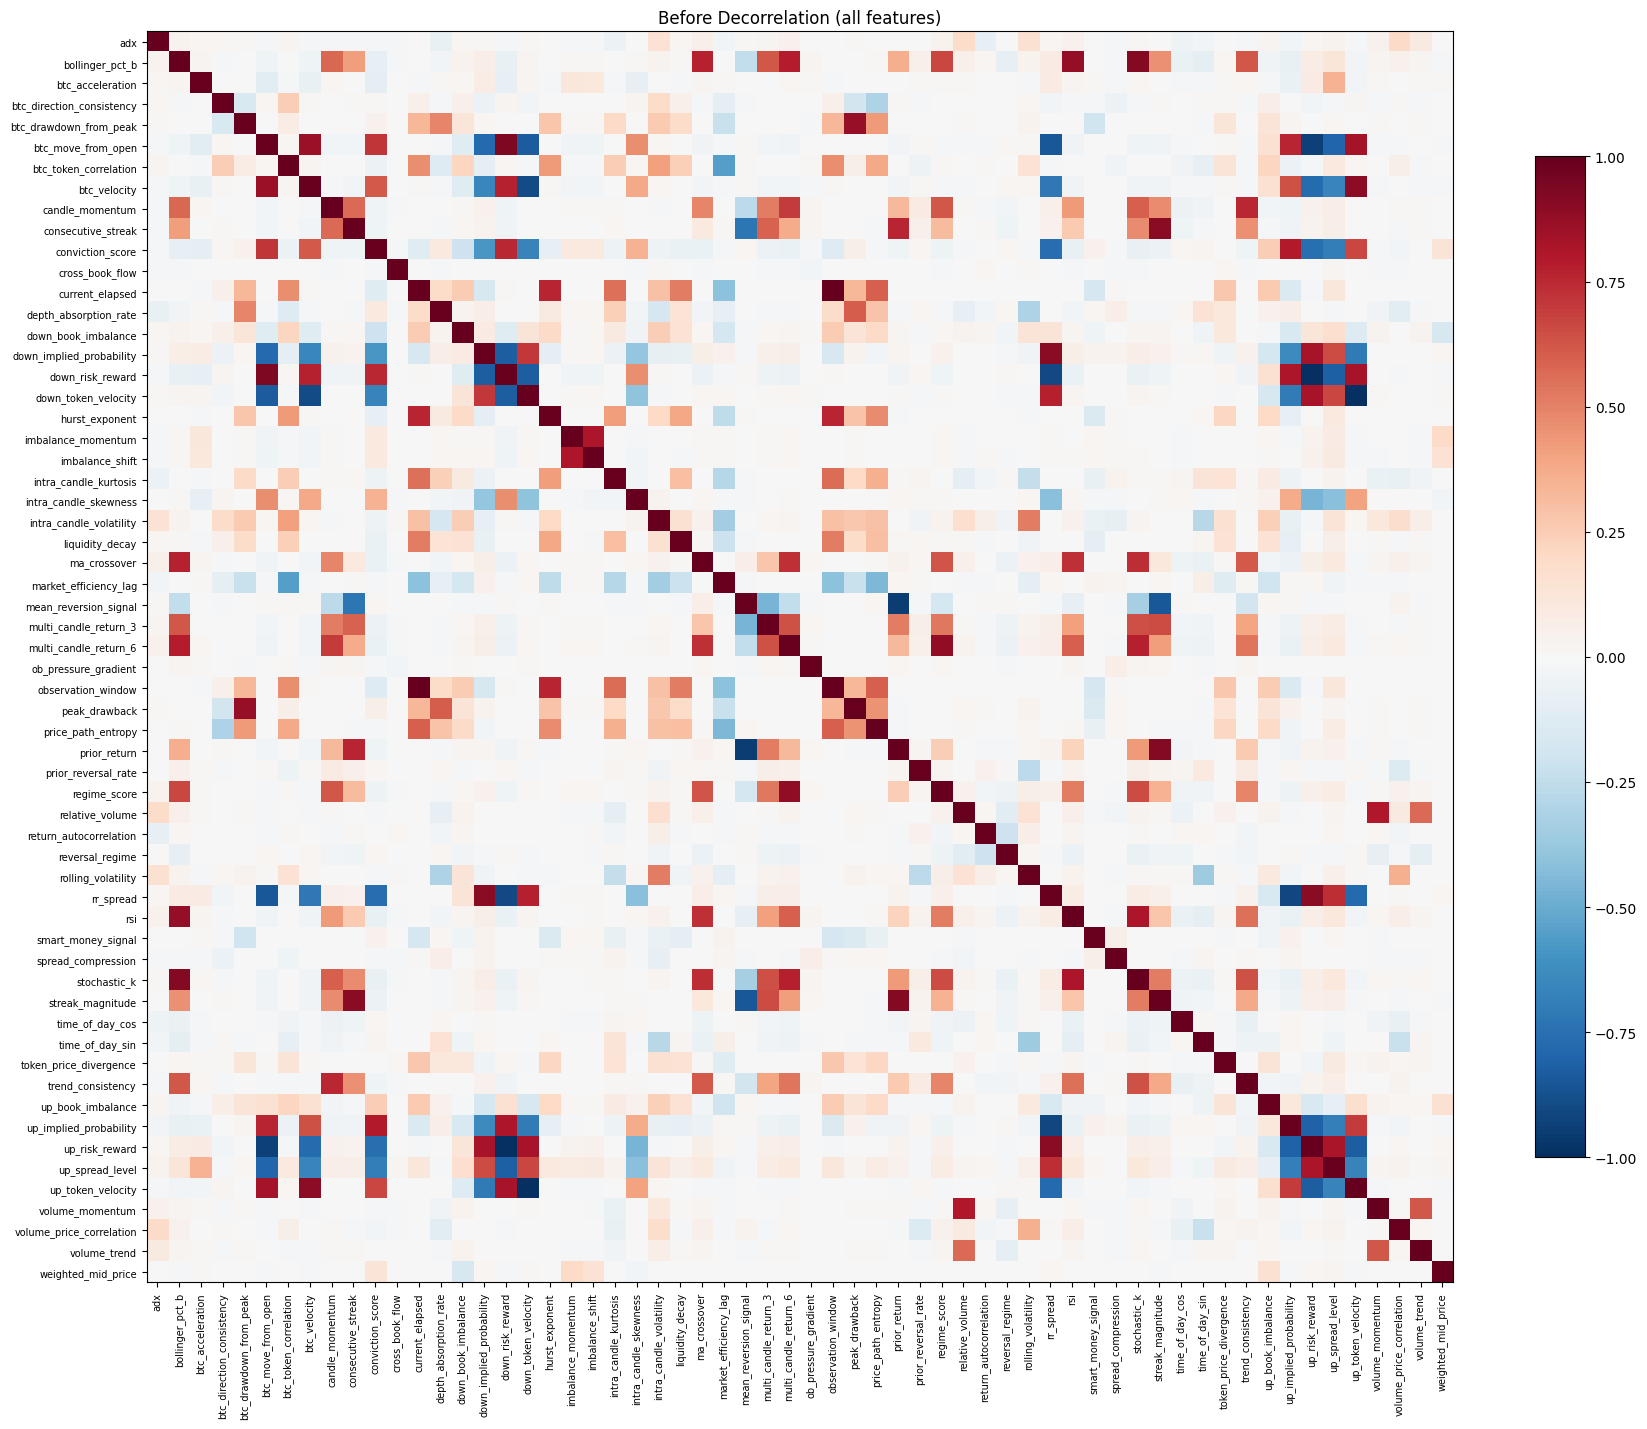


Before: 60 features
After:  37 features (23 dropped)

Clusters with >1 member:
  up_risk_reward (MI=0.2088) <- kept from 11 features
    dropped: ['btc_move_from_open', 'btc_velocity', 'conviction_score', 'down_implied_probability', 'down_risk_reward', 'down_token_velocity', 'rr_spread', 'up_implied_probability', 'up_spread_level', 'up_token_velocity']
  bollinger_pct_b (MI=0.6929) <- kept from 4 features
    dropped: ['ma_crossover', 'rsi', 'stochastic_k']
  streak_magnitude (MI=0.6929) <- kept from 4 features
    dropped: ['consecutive_streak', 'mean_reversion_signal', 'prior_return']
  hurst_exponent (MI=0.0002) <- kept from 3 features
    dropped: ['current_elapsed', 'observation_window']
  candle_momentum (MI=0.0090) <- kept from 2 features
    dropped: ['trend_consistency']
  multi_candle_return_6 (MI=0.6929) <- kept from 2 features
    dropped: ['regime_score']
  imbalance_momentum (MI=0.0389) <- kept from 2 features
    dropped: ['imbalance_shift']
  peak_drawback (MI=0.0037) 

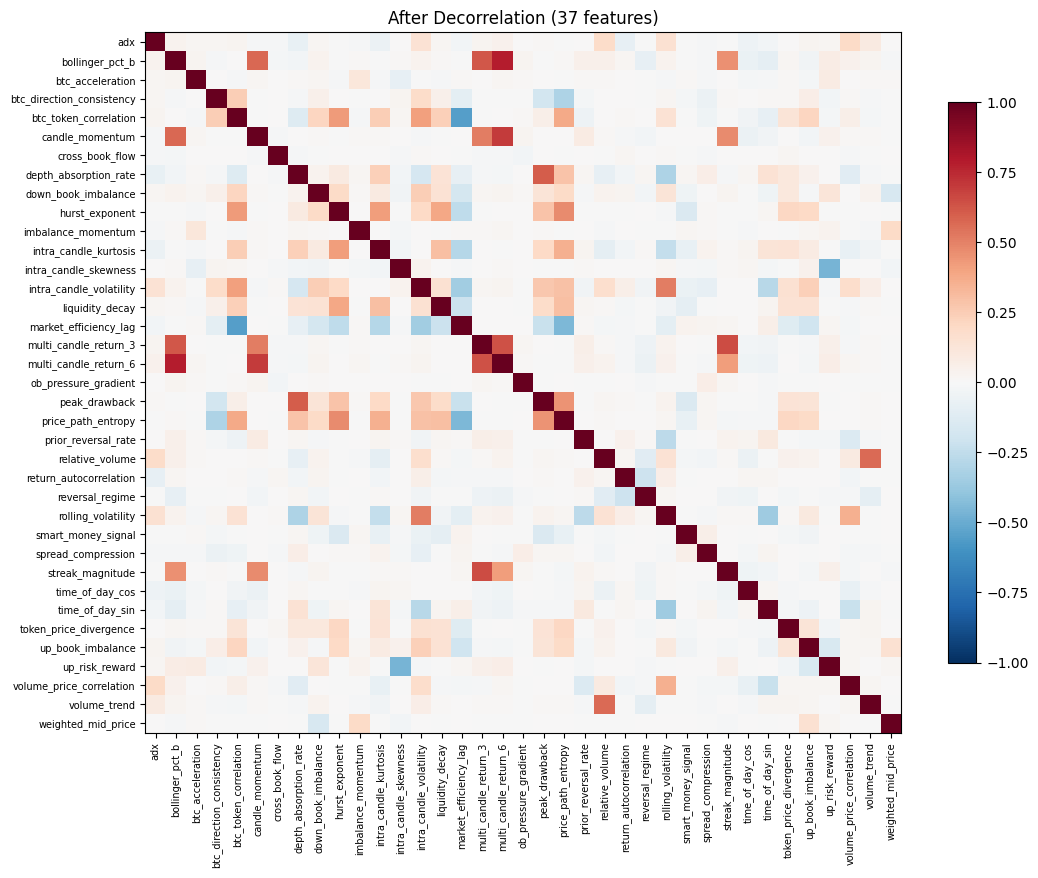

In [3]:
plot_correlation_matrix(df, all_feat_cols, "Before Decorrelation (all features)")

decorr_features, cluster_info = decorrelate_features(
    df,
    all_feat_cols,
    df["target"].values,
    threshold=0.7,
)

print(f"\nBefore: {len(all_feat_cols)} features")
print(f"After:  {len(decorr_features)} features ({len(all_feat_cols) - len(decorr_features)} dropped)")
print("\nClusters with >1 member:")
for feat, info in sorted(cluster_info.items(), key=lambda x: -x[1]["cluster_size"]):
    if info["cluster_size"] > 1:
        print(f"  {feat} (MI={info['mutual_info']:.4f}) <- kept from {info['cluster_size']} features")
        print(f"    dropped: {info['dropped']}")

plot_correlation_matrix(df, decorr_features, f"After Decorrelation ({len(decorr_features)} features)")

## 3. Stage 2: Nested CV with Permutation Importance

**How nested CV works for XGBoost:**

```
Outer fold 1/5:
  ├─ Training data (80%)
  │   └─ Inner GridSearchCV (3-fold) → best hyperparameters
  │   └─ Train final model with best params
  ├─ Validation data (20%)
  │   └─ Permutation importance → which features matter?
  │   └─ Accuracy, F1, Brier → performance metrics
  
Outer fold 2/5: ... (different 80/20 split)
...
```

The inner loop tunes hyperparameters WITHOUT touching the outer validation set.
The outer validation set is used ONLY for feature importance and performance evaluation.
This prevents the information leakage that existed in the old approach.


In [4]:
gkf_outer = GroupKFold(n_splits=5)
gkf_inner = GroupKFold(n_splits=3)
groups = df["candle_id"].values
y = df["target"].values

param_grid = {
    "learning_rate": [0.01, 0.05],
    "max_depth": [3, 6],
    "min_child_weight": [10, 20],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
}

fold_features = []
fold_accs = []
fold_f1s = []
fold_briers = []
fold_params = []
all_importances = []

for fold_i, (train_idx, val_idx) in enumerate(tqdm(gkf_outer.split(df, y, groups=groups), desc="Outer folds")):
    print(f"\n{'=' * 50}")
    print(f"  Outer fold {fold_i + 1}/5")
    print(f"{'=' * 50}")

    X_train_raw = df.iloc[train_idx][decorr_features].values
    X_val_raw = df.iloc[val_idx][decorr_features].values
    y_train = df.iloc[train_idx]["target"].values
    y_val = df.iloc[val_idx]["target"].values
    groups_train = df.iloc[train_idx]["candle_id"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_val = scaler.transform(X_val_raw)

    # Inner CV: tune hyperparameters on training data only
    print("  Tuning hyperparameters (inner 3-fold CV)...")
    inner_search = GridSearchCV(
        xgb.XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42, n_jobs=-1),
        param_grid,
        cv=gkf_inner,
        scoring="accuracy",
        n_jobs=-1,
    )
    inner_search.fit(X_train, y_train, groups=groups_train)
    best_params = inner_search.best_params_
    fold_params.append(best_params)
    print(f"  Best params: {best_params}")

    # Train with best params on full training fold
    best_model = xgb.XGBClassifier(
        n_estimators=200,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        **best_params,
    )
    best_model.fit(X_train, y_train)

    # Permutation importance on validation set (outer fold)
    perm_imp = permutation_importance(best_model, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
    imp_mean = perm_imp.importances_mean
    all_importances.append(imp_mean)

    # Select features with positive permutation importance
    selected = [decorr_features[i] for i in range(len(decorr_features)) if imp_mean[i] > 0]
    fold_features.append(selected)

    # Evaluate
    probs = best_model.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)
    fold_accs.append(accuracy_score(y_val, preds))
    fold_f1s.append(f1_score(y_val, preds))
    fold_briers.append(brier_score_loss(y_val, probs))

    print(f"  Selected: {len(selected)} features")
    print(f"  Acc: {fold_accs[-1] * 100:.1f}%, F1: {fold_f1s[-1] * 100:.1f}%, Brier: {fold_briers[-1]:.4f}")

print(f"\nMean CV: Acc={np.mean(fold_accs) * 100:.1f}% +/- {np.std(fold_accs) * 100:.1f}%")

Outer folds: 0it [00:00, ?it/s]


  Outer fold 1/5
  Tuning hyperparameters (inner 3-fold CV)...
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.7}


Outer folds: 1it [00:25, 25.89s/it]

  Selected: 13 features
  Acc: 74.1%, F1: 75.5%, Brier: 0.1700

  Outer fold 2/5
  Tuning hyperparameters (inner 3-fold CV)...
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 20, 'subsample': 0.8}


Outer folds: 2it [00:50, 25.27s/it]

...

  Selected: 16 features
  Acc: 75.3%, F1: 76.1%, Brier: 0.1645

  Outer fold 4/5
  Tuning hyperparameters (inner 3-fold CV)...
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8}


Outer folds: 4it [01:38, 24.40s/it]

  Selected: 6 features
  Acc: 74.3%, F1: 75.4%, Brier: 0.1679

  Outer fold 5/5
  Tuning hyperparameters (inner 3-fold CV)...
  Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 20, 'subsample': 0.8}


Outer folds: 5it [02:02, 24.57s/it]

  Selected: 20 features
  Acc: 75.6%, F1: 77.2%, Brier: 0.1659

Mean CV: Acc=74.6% +/- 0.7%


### Permutation importance visualization

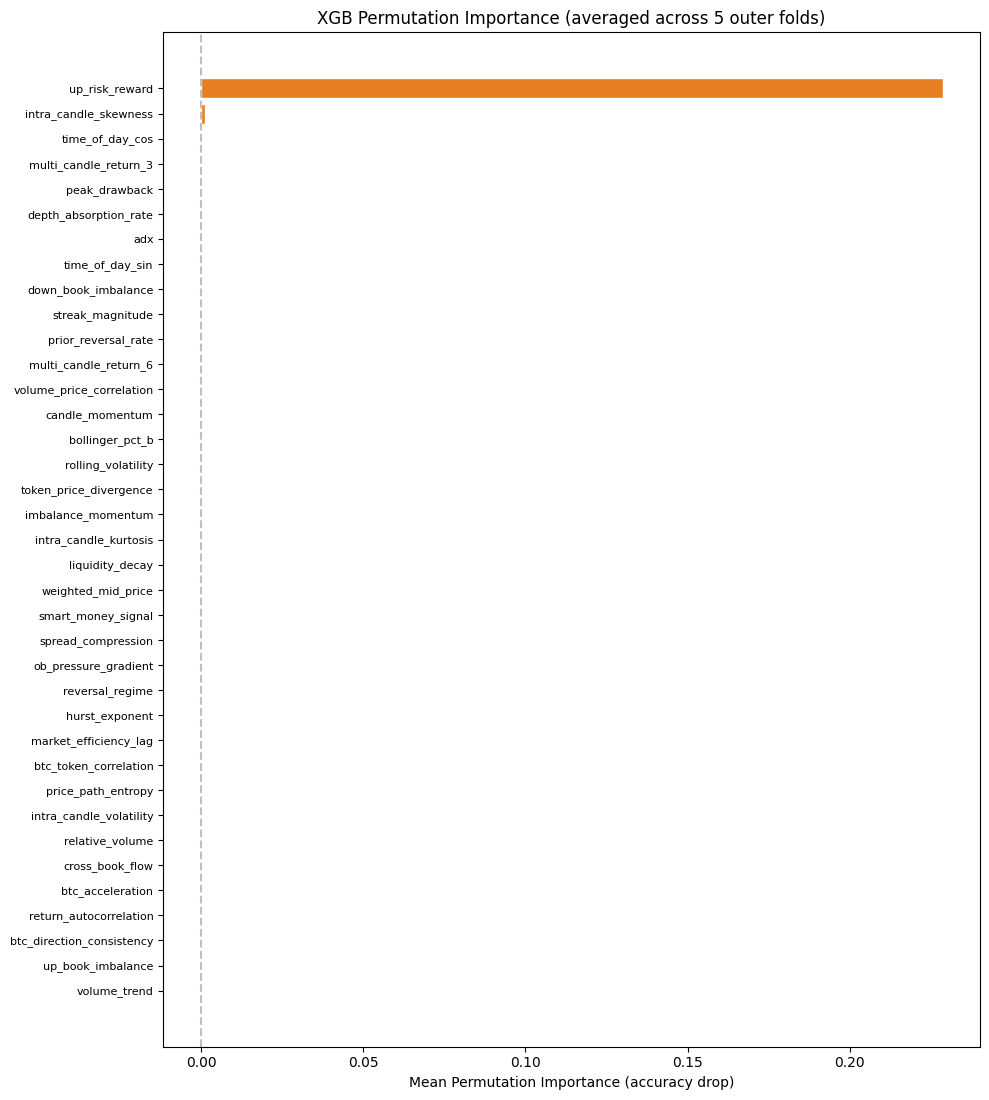

In [5]:
avg_imp = np.mean(all_importances, axis=0)
sorted_idx = np.argsort(avg_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, max(6, len(decorr_features) * 0.3)))
names = [decorr_features[i] for i in sorted_idx]
values = [avg_imp[i] for i in sorted_idx]
colors = ["#e67e22" if v > 0 else "#95a5a6" for v in values]

ax.barh(range(len(names)), values, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Mean Permutation Importance (accuracy drop)")
ax.set_title("XGB Permutation Importance (averaged across 5 outer folds)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Stage 3: Stability Analysis

Features must have positive permutation importance in ≥60% of outer folds to be considered stable.


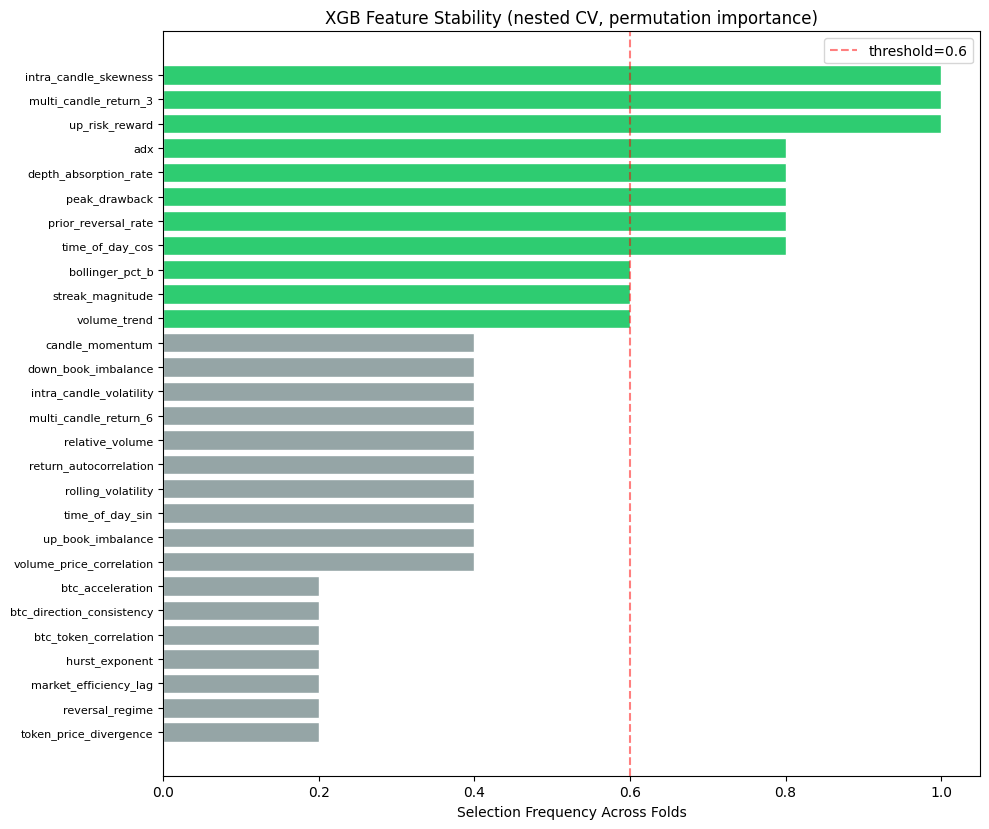


Stable features (positive importance in >=60% of folds): 11
  adx: 80%
  bollinger_pct_b: 60%
  depth_absorption_rate: 80%
  intra_candle_skewness: 100%
  multi_candle_return_3: 100%
  peak_drawback: 80%
  prior_reversal_rate: 80%
  streak_magnitude: 60%
  time_of_day_cos: 80%
  up_risk_reward: 100%
  volume_trend: 60%


In [6]:
stable_features, stability_scores = feature_stability_report(
    fold_features,
    decorr_features,
    threshold=0.6,
)

plot_stability(stability_scores, threshold=0.6, title="XGB Feature Stability (nested CV, permutation importance)")

print(f"\nStable features (positive importance in >=60% of folds): {len(stable_features)}")
for f in stable_features:
    print(f"  {f}: {stability_scores[f] * 100:.0f}%")

## 5. Final evaluation with stable features

In [7]:
# Most common hyperparameters across folds
most_common_params = {}
for key in param_grid:
    values = [p[key] for p in fold_params]
    most_common_params[key] = Counter(values).most_common(1)[0][0]

print(f"Most common hyperparameters across folds: {most_common_params}")

accs, f1s, briers = [], [], []

for train_idx, val_idx in gkf_outer.split(df, y, groups=groups):
    X_train = df.iloc[train_idx][stable_features].values
    X_val = df.iloc[val_idx][stable_features].values
    y_train = df.iloc[train_idx]["target"].values
    y_val = df.iloc[val_idx]["target"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = xgb.XGBClassifier(
        n_estimators=200,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        **most_common_params,
    )
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_val)[:, 1]
    preds = (probs >= 0.5).astype(int)

    accs.append(accuracy_score(y_val, preds))
    f1s.append(f1_score(y_val, preds))
    briers.append(brier_score_loss(y_val, probs))

print(f"\nFinal CV results with {len(stable_features)} stable features:")
print(f"  Accuracy: {np.mean(accs) * 100:.1f}% +/- {np.std(accs) * 100:.1f}%")
print(f"  F1:       {np.mean(f1s) * 100:.1f}% +/- {np.std(f1s) * 100:.1f}%")
print(f"  Brier:    {np.mean(briers):.4f} +/- {np.std(briers):.4f}")

Most common hyperparameters across folds: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8}

Final CV results with 11 stable features:
  Accuracy: 74.6% +/- 0.7%
  F1:       75.6% +/- 1.2%
  Brier:    0.1683 +/- 0.0031


## 6. Save config

In [8]:
# Ensure hyperparams are JSON-serializable native types
serializable_params = {
    k: int(v) if isinstance(v, np.integer) else float(v) if isinstance(v, np.floating) else v
    for k, v in most_common_params.items()
}

config = {
    "model": "xgboost",
    "features": stable_features,
    "n_features": len(stable_features),
    "accuracy_cv_mean": round(float(np.mean(accs)), 4),
    "accuracy_cv_std": round(float(np.std(accs)), 4),
    "f1_cv_mean": round(float(np.mean(f1s)), 4),
    "brier_cv_mean": round(float(np.mean(briers)), 4),
    "selection_method": "nested_cv_permutation_importance",
    "cv_folds": 5,
    "stability_threshold": 0.6,
    "feature_stability": {f: round(stability_scores[f], 2) for f in stable_features},
    "decorrelation_threshold": 0.7,
    "features_before_decorrelation": len(all_feat_cols),
    "features_after_decorrelation": len(decorr_features),
    "hyperparameters": serializable_params,
    "calibrated": True,
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_features_xgb.json")
with open(out_path, "w") as f:
    _json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} XGB features to {out_path}")
print(f"Features: {config['features']}")
print(f"Hyperparameters: {config['hyperparameters']}")

Saved 11 XGB features to ../../data/optimal_features_xgb.json
Features: ['adx', 'bollinger_pct_b', 'depth_absorption_rate', 'intra_candle_skewness', 'multi_candle_return_3', 'peak_drawback', 'prior_reversal_rate', 'streak_magnitude', 'time_of_day_cos', 'up_risk_reward', 'volume_trend']
Hyperparameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8}


## Conclusion

Feature selection pipeline:
1. **Decorrelation**: collapsed correlated features using Spearman clustering (|ρ| > 0.7)
2. **Nested CV**: outer 5-fold for evaluation, inner 3-fold for hyperparameter tuning (no leakage)
3. **Permutation importance**: computed on outer validation folds (unbiased)
4. **Stability**: kept features with positive importance in ≥60% of outer folds

This replaces the old approach which:
- Used impurity importance (biased by correlation)
- Tuned hyperparameters on the same validation set used for evaluation (leakage)
- Used a single train/val split (overfitting to one specific split)

Run `xgb/02_export.ipynb` to export the model, then `xgb/03_strategy.ipynb` for strategy discovery.
